# Linear Regression

Linear Regression একটি মৌলিক regression algorithm যা **continuous target variable** এবং **feature গুলোর মধ্যে linear relationship** শিখতে ব্যবহার করা হয়।

$$
y = X\beta + \varepsilon
$$

- `X` = Features matrix  
- `y` = Target variable  
- `β` = Model coefficients  
- `ε` = Noise / error

scikit-learn এর `LinearRegression` OLS (Ordinary Least Squares) ব্যবহার করে **best-fit coefficients** বের করে।

## 1. Dataset Load

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


`from sklearn.datasets import load_diabetes` ব্যবহার করে আমরা scikit-learn এর built-in **diabetes dataset** import করি। scikit-learn অনেক sample datasets প্রদান করে, যা আমাদের **machine learning practice** এবং বিভিন্ন algorithm পরীক্ষা করার জন্য ব্যবহার হয়। `load_diabetes()` হলো একটি function যা dataset কে Python object আকারে return করে।

Dataset কে আরও সুবিধাজনকভাবে দেখার জন্য আমরা pandas import করি: `import pandas as pd`। pandas হলো একটি **data manipulation library**, যা আমাদের feature এবং target কে **DataFrame আকারে readable এবং manipulative** করতে সাহায্য করে।

`diabetes = load_diabetes()` দিয়ে dataset load করা হলো। এটি একটি **dictionary-like object**, যার মধ্যে বিভিন্ন key থাকে। যেমন, `data` key-তে features এর মূল 2D array থাকে, `target` key-তে target variable থাকে, এবং `feature_names` key-তে প্রতিটি feature এর নাম থাকে। এছাড়া dataset সংক্রান্ত অন্যান্য metadata যেমন description ও পাওয়া যায়।

সব features ১০টি baseline variables `X = diabetes.data` এ রাখা হলো। এটি মূলত একটি **2D NumPy array**, যেখানে **row = sample** এবং **column = feature**। Machine learning algorithms এই array কে input হিসেবে ব্যবহার করে। Target variable `y = diabetes.target` এ সংরক্ষণ করা হয়। Diabetes dataset এ target হলো রোগের progression measure, যা আমাদের predict করতে হবে। এটি একটি **1D array**, যেখানে প্রতিটি entry একটি patient এর disease progression score।

Features এর নামগুলো সংরক্ষণ করে রাখতে আমরা `feature_names = diabetes.feature_names` ব্যবহার করি। এগুলো DataFrame এর column name হিসেবে ব্যবহার করা হয়, যাতে dataset **readable এবং interpretable** হয়। এরপর `df = pd.DataFrame(X, columns=feature_names)` দিয়ে features কে **pandas DataFrame** আকারে রূপান্তর করা হয়। DataFrame আমাদের dataset কে **table structure** দেয়, যেখানে প্রতিটি column একটি feature এবং row একটি sample। এটি বিশ্লেষণ এবং visualization অনেক সহজ করে।

Target variable DataFrame-এ যোগ করা হলো: `df['target'] = y`। এখন DataFrame এ সব features এবং target একসাথে আছে। এটি আমাদের **ML pipeline** তৈরির জন্য প্রয়োজনীয়। অবশেষে, `print(df.head())` ব্যবহার করে আমরা DataFrame এর **প্রথম ৫টি row** দেখতে পারি। এটি dataset এর **structure, features, এবং target distribution** বোঝার জন্য গুরুত্বপূর্ণ। প্রথম কয়েকটি row দেখে আমরা dataset কেমন, কোন feature এর value scale কেমন, এবং target distribution কেমন তা সহজে বুঝতে পারি।

## 2. Train-Test Split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ডেটাসেটকে training এবং testing সেটে ভাগ করার কাজ খুবই গুরুত্বপূর্ণ। এটি করার জন্য আমরা `train_test_split` ব্যবহার করি, যা dataset কে দুটি অংশে ভাগ করে: training set এবং testing set। Training set হলো সেই অংশ যেখানে আমাদের model শিখবে, অর্থাৎ features এবং target variable এর relationship ধরতে শিখবে। Testing set হলো সেই অংশ যা model এর performance যাচাই করার জন্য আলাদা রাখা হয়, যাতে model **unseen data** এ কেমন কাজ করে তা দেখা যায়।

Training এবং testing set ভাগ করার সময় আমরা সাধারণত dataset এর ২০% অংশ test set হিসেবে রাখি। অর্থাৎ ৮০% ডেটা training এর জন্য এবং ২০% ডেটা evaluation এর জন্য ব্যবহৃত হয়। এটি model evaluation কে **scientific এবং unbiased** করে। যদি সব ডেটা একসাথে ব্যবহার করে train করি, তাহলে model overfit হতে পারে এবং বাস্তব ডেটাতে ভালো predictive performance দিতে পারবে না।

`random_state` parameter ব্যবহার করা হয় যাতে dataset split reproducible হয়। অর্থাৎ প্রতিবার যখন আমরা কোড চালাই, একইভাবে training এবং testing data ভাগ হবে। এটি analysis consistency এবং debugging এর জন্য দরকার।

split করার পর আমাদের চারটি main object পাওয়া যায়: `X_train`, `X_test`, `y_train`, এবং `y_test`। `X_train` এবং `y_train` model training এর জন্য ব্যবহার হয়। অর্থাৎ model এই ডেটা দেখে learn করে feature এবং target এর মধ্যে relationship তৈরি করতে পারে। `X_test` এবং `y_test` model evaluation এর জন্য রাখা হয়। Training set দিয়ে model train হওয়ার পর, testing set দিয়ে আমরা model predict করতে পারি এবং prediction এর সাথে actual target compare করে model এর **accuracy, error, এবং generalization capability** যাচাই করতে পারি।

এইভাবে training এবং testing data আলাদা রাখা machine learning এর একটি গুরুত্বপূর্ণ best practice। এটি নিশ্চিত করে যে model কেবল training data মনে রাখছে না, বরং **নতুন এবং unseen data** এ কেমন কাজ করবে সেটিও বুঝাতে পারছে।

## 3. Linear Regression Model Fitting

In [3]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

Linear Regression মডেল তৈরি করার জন্য প্রথমে scikit-learn থেকে `LinearRegression` class import করা হয়। এটি মূল class যা model training, prediction এবং coefficients নির্ণয় করার জন্য ব্যবহৃত হয়। এরপর একটি LinearRegression object তৈরি করা হয়। Object তৈরি করার সময় কিছু important parameters থাকে। যেমন `fit_intercept=True` থাকলে model automatically একটি **intercept** শেখে। অর্থাৎ, যখন সব features এর মান শূন্য থাকে, তখন target variable কত হবে তা model এই intercept দ্বারা নির্ধারণ করে। আর `normalize=False` দ্বারা নির্দেশ দেওয়া হয় যে training data কে আলাদাভাবে normalize করা হবে না।

Model তৈরি হওয়ার পর `fit` method ব্যবহার করে training data দিয়ে model train করা হয়। এখানে training data হলো `X_train` এবং `y_train`। LinearRegression class Ordinary Least Squares (OLS) ব্যবহার করে **best-fit coefficients** বের করে, যা feature এবং target এর মধ্যে linear relationship কে সবচেয়ে ভালোভাবে capture করে। Training process শেষে আমাদের model জানে কোন feature কতটা weight রাখবে এবং intercept কত হবে, যাতে predictions loss minimize করা যায়।

এইভাবে model training শেষ হলে আমরা coefficients এবং intercept ব্যবহার করে **unseen data** এর উপর predictions করতে পারি এবং feature importance এবং relationship বুঝতে পারি। Training process এর মূল উদ্দেশ্য হলো feature ও target এর মধ্যে linear mapping শিখে accurate predictions তৈরি করা।

## 4. Prediction

In [4]:
y_pred = lr.predict(X_test)

Model training শেষ হওয়ার পরে আমরা unseen বা test data এর উপর predictions করি। Linear Regression এর ক্ষেত্রে এটি করা হয় `predict` method ব্যবহার করে। Prediction মানে হলো model পূর্বে শিখে নেওয়া **coefficients** এবং **intercept** ব্যবহার করে test set এর features থেকে target এর সম্ভাব্য মান বের করা।

Mathematically, prediction হয় এইভাবে:
$$
y_{pred} = X_{test} \cdot \beta + intercept
$$

এখানে `X_test` হলো test set এর features, `β` হলো training set থেকে শেখা model coefficients এবং `intercept` হলো সেই value যা সব features শূন্য থাকলে target কত হবে তা নির্দেশ করে। Model prediction এর সময় intercept ব্যবহার করা হয় যাতে base value ঠিক থাকে।

এই process এ model প্রতিটি test sample এর জন্য **linear combination** হিসাব করে। অর্থাৎ, প্রতিটি feature এর মানকে corresponding coefficient দ্বারা গুণ করা হয় এবং সবগুলো যোগ করা হয়। শেষে intercept যোগ করলে আমাদের **predicted target value** পাওয়া যায়।

Prediction করার মূল উদ্দেশ্য হলো model এর **generalization capability** যাচাই করা। আমরা দেখতে চাই model শুধুমাত্র training data মনে রাখছে না, বরং **unseen test data** এর উপরও কতটা সঠিকভাবে target predict করতে পারছে। Prediction এর মান পরে **error analysis, residual analysis এবং performance metrics** নির্ণয়ের জন্য ব্যবহার করা হয়।

## 5. Evaluation (MSE & R²)

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R^2: {r2:.4f}, MSE: {mse:.4f}")

R^2: 0.4526, MSE: 2900.1936


Linear Regression মডেলের performance মূল্যায়ন করার জন্য আমরা **evaluation metrics** ব্যবহার করি। scikit-learn থেকে `mean_squared_error` এবং `r2_score` import করা হয়। `mean_squared_error` মেট্রিকটি model এর prediction এবং আসল target এর মধ্যে **residuals** বা prediction error পরিমাপ করে। Residuals গণনা হয় প্রতিটি sample এর জন্য `(y_true - y_pred)` হিসেবে। এরপর এই residuals এর **square** করে সবগুলো mean নেওয়া হয়, যা আমাদের **Mean Squared Error (MSE)** দেয়। MSE যত ছোট হবে, model prediction তত বেশি accurate এবং residual কম। এটি মূলত আমাদের বলে দেয় model কতটা ভালোভাবে test data কে predict করতে পারছে।

`r2_score` হলো **goodness-of-fit** measure। এটি model prediction এবং actual data এর মধ্যে correlation বা explanatory power দেখায়। R² এর মান ১ হলে model perfect prediction করছে, অর্থাৎ residuals শূন্য। R² এর মান ০ হলে model শুধু target এর mean ব্যবহার করে prediction করছে এবং কোন explanatory power নেই। R² এর মান যত ১ এর কাছাকাছি হবে, model তত ভালো fit হয়েছে।

শেষে `print()` ব্যবহার করে আমরা MSE এবং R² এর মান দেখাই। এটি একটি **concise summary** দেয় যে আমাদের trained Linear Regression model কতটা ভালো perform করছে, residuals কি পর্যায়ের, এবং model কতটা generalized। এই ধাপটি খুব গুরুত্বপূর্ণ কারণ শুধুমাত্র training data এ ভালো performance মানে model বাস্তবে ভালো predict করবে এমন নয়; test data evaluation নিশ্চিত করে model এর **real-world applicability**।

## 6. Coefficients & Intercept

In [6]:
coef = pd.Series(lr.coef_, index=feature_names).sort_values(key=abs, ascending=False)
print("\nTop coefficients (abs মান অনুযায়ী):")
print(coef)
print("Intercept:", lr.intercept_)


Top coefficients (abs মান অনুযায়ী):
s1    -931.488846
s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
sex   -241.964362
s3     163.419983
s6      48.670657
age     37.904021
dtype: float64
Intercept: 151.34560453985995


Linear Regression মডেলের **coefficients** এবং **intercept** model এর behavior বোঝার জন্য খুবই গুরুত্বপূর্ণ। `lr.coef_` হলো প্রতিটি feature এর weight বা coefficient। এটি নির্দেশ করে প্রতিটি feature কতটা প্রভাব ফেলে target variable এর উপর। উদাহরণস্বরূপ, একটি feature এর coefficient বড় এবং positive হলে, সেই feature এর মান বৃদ্ধির সাথে সাথে target variable ও বৃদ্ধি পাবে। আবার negative coefficient মানে feature এবং target এর মধ্যে inverse সম্পর্ক।

`lr.intercept_` হলো model এর **intercept**। এটি নির্ধারণ করে যখন সব features এর মান শূন্য থাকবে, তখন target variable কত হবে। Intercept মূলত base value হিসেবে কাজ করে, যাতে predictions feature values শূন্য হলেও logical থাকে।

Coefficient গুলোকে readable format এ দেখতে আমরা pandas Series ব্যবহার করি: `pd.Series(lr.coef_, index=feature_names)`। এতে প্রতিটি coefficient কে corresponding feature name এর সাথে map করা যায়, যা আমাদের বোঝায় কোন feature কতটা গুরুত্বপূর্ণ।

Feature importance আরও ভালোভাবে বোঝার জন্য coefficients কে absolute মান অনুযায়ী sort করা হয়: `.sort_values(key=abs, ascending=False)`। এতে descending order এ সবচেয়ে গুরুত্বপূর্ণ feature প্রথমে দেখা যায়।

**coefficients এবং intercept একসাথে prediction তৈরি করে**। Coefficients দ্বারা feature এর contribution নির্ধারিত হয়, আর intercept দ্বারা base value ঠিক থাকে। এটি model interpretability এর জন্য অত্যন্ত গুরুত্বপূর্ণ, কারণ আমরা বুঝতে পারি কোন feature target কে কতটা প্রভাবিত করছে এবং model কিভাবে prediction তৈরি করছে।

## 7. Residual Analysis (Error Distribution)

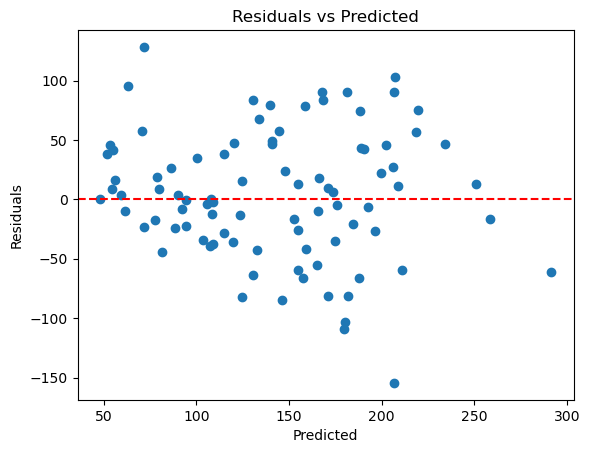

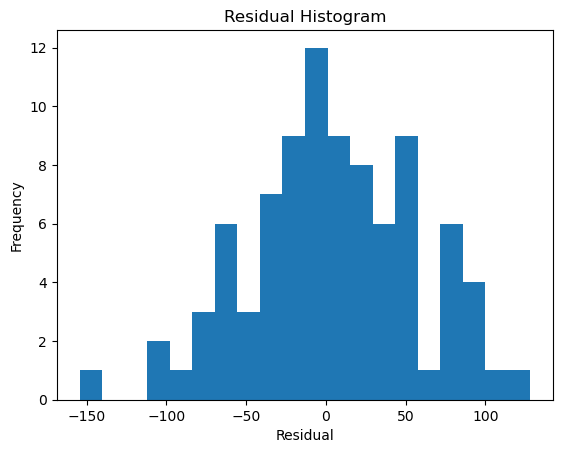

In [7]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

plt.hist(residuals, bins=20)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residual Histogram')
plt.show()

Residuals হলো model prediction এর **error**, অর্থাৎ prediction এবং আসল target এর মধ্যে পার্থক্য। এটি গণনা করা হয় `y_test - y_pred` দ্বারা। প্রতিটি test sample এর জন্য residual মানে হলো model কতটা সঠিকভাবে target predict করতে পেরেছে। ছোট residual মানে prediction accurate, বড় residual মানে model ভুল করেছে।

Residual analysis আমাদের দেখায় model এর **prediction bias বা systematic pattern** আছে কিনা। যদি residuals random ভাবে scatter করে, তবে model ঠিকভাবে learn করেছে। কিন্তু যদি residuals এ কোন pattern দেখা যায়, যেমন increasing trend বা curve, তবে এটি নির্দেশ করে model **feature-target relationship capture করতে পারছে না**, অথবা কোন non-linear relationship উপেক্ষা হয়েছে।

Residuals visualization এর জন্য আমরা সাধারণত **residual plot** ব্যবহার করি। Residual plot এ x-axis এ predicted value বা feature এবং y-axis এ residual থাকে। Plot এ একটি horizontal line আঁকা হয় `y = 0` (axhline 0), যা ideal residual line নির্দেশ করে। Residual মানগুলো যদি এই line এর চারপাশে random scatter করে থাকে, তবে model unbiased এবং well-fitted।

Residuals এর distribution যাচাই করার জন্য আমরা **histogram** ব্যবহার করি। Histogram residual এর frequency distribution দেখায়। Linear Regression এর জন্য একটি গুরুত্বপূর্ণ assumption হলো residuals প্রায় **normal distribution** এ হওয়া। Histogram এ residual normal distribution অনুসারে centered থাকলে model assumptions satisfy হয়। যদি distribution skewed বা irregular হয়, তবে model improvement বা transformation প্রয়োজন হতে পারে।

residual analysis আমাদের model এর **accuracy, bias, এবং assumptions validation** বোঝায়। এটি একটি গুরুত্বপূর্ণ ধাপ, কারণ শুধুমাত্র metrics যেমন MSE বা R² যথেষ্ট নয়; residuals এ pattern দেখা দিলে আমরা বুঝতে পারি model কোথায় ঠিক predict করছে না।

## 8. Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

neg_mse_scores = cross_val_score(lr, X, y, cv=5, scoring='neg_mean_squared_error')
mse_scores = -neg_mse_scores
print("CV MSE:", mse_scores)
print("Mean CV MSE:", mse_scores.mean())

CV MSE: [2779.92344921 3028.83633883 3237.6875877  3008.74648884 2910.21268776]
Mean CV MSE: 2993.0813104693307


Cross-validation হলো model evaluation এর একটি গুরুত্বপূর্ণ technique, যা আমাদের model এর **generalization capability** বোঝায়। scikit-learn এর `cross_val_score` function ব্যবহার করে dataset কে **multiple folds** এ ভাগ করা হয়। সাধারণভাবে, dataset কে K ভাগ করা হয়, যেখানে K-1 ভাগ model training এর জন্য এবং বাকি 1 ভাগ validation এর জন্য রাখা হয়। এই process প্রতিটি fold এর জন্য repeat হয় যাতে dataset এর সব অংশ model validation এ ব্যবহার হয়।

Cross-validation এর সময় scoring metric হিসেবে আমরা ব্যবহার করতে পারি `neg_mean_squared_error`। scikit-learn conventionally negative value return করে, কারণ higher score সাধারণত ভালো বোঝায়। কিন্তু MSE ক্ষেত্রে lower value ভালো, তাই আমরা সাধারণত `-1` দ্বারা convert করে positive MSE পাই। প্রতিটি fold এর জন্য আলাদা MSE পাওয়া যায়, যা আমাদের দেখায় model কত consistency সহ predict করতে পারছে।

শেষে, সব folds এর MSE এর mean নিয়ে আমরা **average model performance** পাই। Mean MSE ছোট হলে বোঝায় model সব dataset partitions এ ভালো predict করতে পারছে। Cross-validation সাধারণ train-test split এর চেয়ে আরও robust evaluation দেয়, কারণ এটি model কে dataset এর বিভিন্ন অংশে test করে এবং overfitting বা variance সম্পর্কে ধারণা দেয়।

cross-validation মডেলকে **training bias এবং generalization error** নির্ধারণের জন্য একটি শক্তিশালী tool। এটি নিশ্চিত করে যে model কেবল training data মনে রাখছে না, বরং unseen data এর উপরও predict করতে পারছে।